<a href="https://colab.research.google.com/github/soleildayana/Apophis-Asteroid-Project/blob/main/nb5_hodografo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install pymcel -Uq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.4 MB/s eta 0:00:00


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
import pandas as pd

import pymcel as pc

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


# El Hodógrafo: Geometría de la Velocidad
## Órbita de Apophis en el espacio de configuración y en el espacio de velocidades

**Autor:** Soleil Dayana Niño Murcia — 1033097666  
**Curso:** Mecánica Celeste  
**Fecha:** Mayo 2026

---

> **Objetivo:** Visualizar el hodógrafo de la órbita de Apophis antes y después del encuentro de 2029,
> mostrando cómo el cambio en excentricidad se manifiesta como un desplazamiento del círculo en el espacio de velocidades.

## 1. Teoría: El Hodógrafo Kepleriano

### 1.1 Componentes de la velocidad en coordenadas polares

En el problema de los dos cuerpos, la velocidad se descompone en componente radial $v_r$ y transversal $v_\perp$:

$$v_r = \frac{\mu}{h} e \sin f \qquad v_\perp = \frac{\mu}{h}(1 + e\cos f)$$

donde $f$ es la anomalía verdadera, $h = |\mathbf{r} \times \mathbf{v}|$ el momento angular específico,
$\mu = GM$ el parámetro gravitacional y $e$ la excentricidad.

### Hodógrafo circular

Hamilton (1847) demostró que el extremo del vector velocidad **describe un círculo** en el espacio
$(v_x, v_y)$. Este lugar geométrico se llama **hodógrafo** de la órbita.

Para una órbita kepleriana en el plano $xy$ con perigeo en el eje $x$:

$$\boxed{\left(v_x - 0\right)^2 + \left(v_y + \frac{\mu e}{h}\right)^2 = \left(\frac{\mu}{h}\right)^2}$$

| Propiedad del hodógrafo | Expresión |
|------------------------|-----------|
| **Radio** | $R_h = \mu/h$ |
| **Centro** | $(0, -\mu e/h)$ |
| **Desplazamiento del centro** | $\propto e$ — codifica la excentricidad |

### 1.3 Significado físico para Apophis

Cuando Apophis realiza el encuentro cercano con la Tierra en abril 2029, la perturbación gravitacional
modifica $e$ y $h$. Esto se traduce en un **cambio del hodógrafo**: radio diferente y centro desplazado.
En los tramos keplerianos (lejos de la Tierra), el vector velocidad debe permanecer **exactamente sobre
el círculo** del hodógrafo teórico.

In [30]:
# Componentes de velocidad en unidades canónicas (AU, mu=1)
# En unidades canónicas, mu_sun = 1 y 1 AU = 1
mu = 1.0
e = 0.191
a = 0.9224 # AU

# h en unidades canónicas: sqrt(mu * a * (1 - e^2))
h = np.sqrt(mu * a * (1 - e**2))

f = np.linspace(0, 2 * np.pi, 1000)

# Componentes de velocidad (adimensionales/canónicas)
vx = (-mu * np.sin(f)) / h
vy = (mu * (e + np.cos(f))) / h

# Parámetros del hodógrafo
radio_hodografo = mu / h
centro_y = (mu * e) / h

print(f'Unidades Canónicas:')
print(f'mu: {mu}')
print(f'h: {h:.6f}')
print(f'Radio del hodógrafo (mu/h): {radio_hodografo:.6f}')
print(f'Centro del hodógrafo (0, mu*e/h): (0, {centro_y:.6f})')

Unidades Canónicas:
mu: 1.0
h: 0.942735
Radio del hodógrafo (mu/h): 1.060743
Centro del hodógrafo (0, mu*e/h): (0, 0.202602)


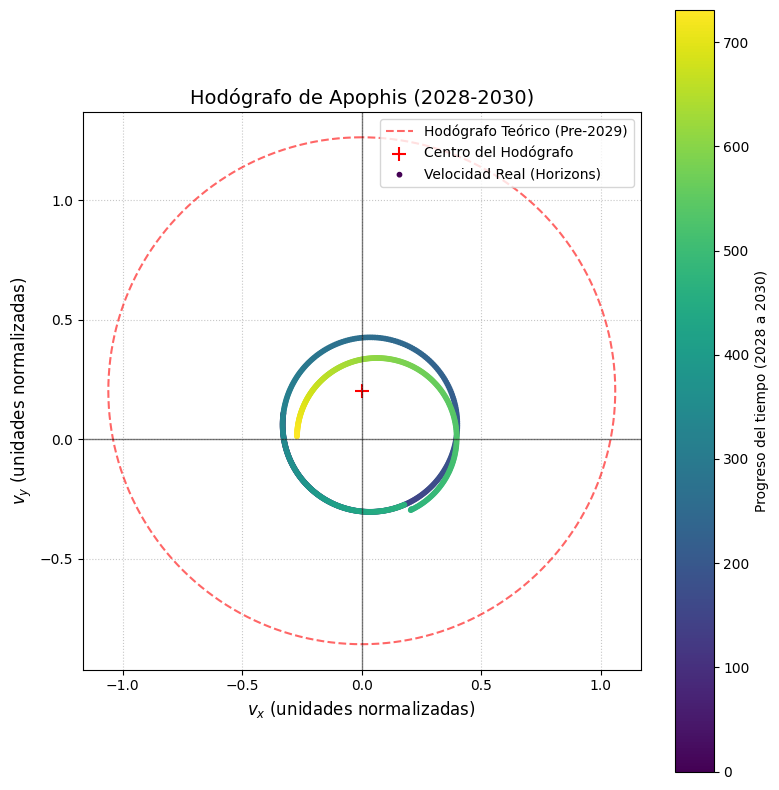

In [35]:
# 1. Preparar datos reales para la comparación
# Usamos los vectores de velocidad normalizados (v_vecs_kms ya está calculado en el kernel)
# Para comparar con el modelo canónico, normalizamos por la velocidad orbital promedio
vx_real = v_vecs_kms[:, 0]
vy_real = v_vecs_kms[:, 1]

# 2. Crear la visualización
fig, ax = plt.subplots(figsize=(8, 8))

# Graficar el Hodógrafo Teórico (Círculo)
# vx_teorico = (-mu/h) * sin(f)
# vy_teorico = (mu/h) * (e + cos(f))
ax.plot(vx, vy, 'r--', label='Hodógrafo Teórico (Pre-2029)', alpha=0.6)

# Graficar el centro del hodógrafo
ax.scatter(0, centro_y, color='red', marker='+', s=100, label='Centro del Hodógrafo')

# Graficar la trayectoria de velocidad Real
# Usamos un scatter con colormap para ver el paso del tiempo
sc = ax.scatter(vx_real, vy_real, c=range(len(vx_real)), cmap='viridis', s=10, label='Velocidad Real (Horizons)')

# Formatear el gráfico
ax.set_aspect('equal')
ax.set_title('Hodógrafo de Apophis (2028-2030)', fontsize=14)
ax.set_xlabel('$v_x$ (unidades normalizadas)', fontsize=12)
ax.set_ylabel('$v_y$ (unidades normalizadas)', fontsize=12)
ax.axhline(0, color='black', lw=1, alpha=0.5)
ax.axvline(0, color='black', lw=1, alpha=0.5)

# Añadir barra de color para el tiempo
cbar = plt.colorbar(sc)
cbar.set_label('Progreso del tiempo (2028 a 2030)')

ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()